# Cortical TRF analysis 2: neural speech restoration at the cocktail party

This notebook runs the same kinds of analyses as Brodbeck et al. 2020
(PLOS Biology), "Neural speech restoration at the cocktail party", on this
project's own EEG dataset (13 subjects) instead of their 26-subject MEG
dataset. Cells that match one of their reported comparisons carry a short
comment naming the result they found, as a point of reference - not a
target this dataset is expected to hit. Different dataset, different
modality, a much smaller group: matching the *methodology* is the goal,
not reproducing their exact numbers.

**Renaming from `cortical_analysis.ipynb`:** foreground -> **attend**,
background -> **ignore**, mixture stays **mix**. This only changes labels
and variable names in this notebook - `experiment.py`'s `label_events()`
still populates `ds['fg']`/`ds['bg']`/`ds['mix']` under those original
names, shared with the other notebook.

**Frequency resolution:** 8-band predictors (`gammatone-8`,
`gammatone-on-8`) throughout, not the 1-band versions
`cortical_analysis.ipynb` mostly uses, so TRFs can be examined per
frequency band (an STRF - spectro-temporal response function).

## Structure

Organized by listening condition, each as its own section: clean speech,
then diotic, dichotic-left, dichotic-right, and binaural - each of the
four two-talker conditions further split into its own base section plus
overt-onset, masked-onset, and intensity-level-control subsections. Every
subsection is self-contained: the same handful of shared helper functions
(defined once below) get called with that subsection's own predictors and
`epoch`. Cells run top to bottom; `data`, `diff`, `result`, `data_full`,
`data_masked`, `p` are reused generically across subsections the same way
`cortical_analysis.ipynb` reuses `data`/`p`/`dss` - what a cell overwrites
is always exactly what the cell right before it just produced.

**One fit per model per condition.** `FULL_BASE` (the plain attend/
ignore/mix model) and `FULL_MASKED` (the overt/masked version) are each
fit with `e.load_trfs()` exactly once per condition, into `data_full`/
`data_masked` - every STRF, peak-timing, waveform, and attention-effect
cell that needs one of those predictors reads a column out of that
already-loaded result instead of re-fitting the same model again. Only
the unique-contribution/direct-comparison cells call `e.load_model_test()`
on their own, since a model *comparison* is a different derivative than
a plain TRF fit and can't be read out of `data_full`/`data_masked`.

In [1]:
from eelbrain import *
from experiment import e, topomap_with_colorbar, FIGURES_DIR
import matplotlib.pyplot as plt
import numpy
import seaborn as sns

# Where to save plots - inside the BIDS dataset's derivatives, same as
# cortical_analysis.ipynb, not somewhere outside the dataset.
DST = FIGURES_DIR

INFO    :  *** BinauralCocktail initialized with root /Users/joshuaighalo/Github Repositories/dataset/cocktail/bids on 2026-09-13 14:22:55 ***
INFO    :  Using eelbrain 0.0.0, mne 1.12.1.


## Preprocessing (run once per subject)

Identical to `cortical_analysis.ipynb` - both notebooks use the same
preprocessed EEG (`raw='ica'`), so this only does real work the first time
either notebook is run for a given subject.

In [2]:
MANUAL_BAD_CHANNELS = False
AUTO_BAD_CHANNELS_R = 0.3
REDO_BAD_CHANNELS = True

e.mark_bad_channels(
    'all',
    manual_bad_channels=MANUAL_BAD_CHANNELS, auto_bad_channels_r=AUTO_BAD_CHANNELS_R,
    redo_bad_channels=REDO_BAD_CHANNELS,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. Bad channels marked.


In [3]:
MANUAL_ICA = False
AUTO_ICA_CONFIDENCE = 0.75

e.select_ica_artifacts(
    'all',
    manual_ica=MANUAL_ICA, auto_ica_confidence=AUTO_ICA_CONFIDENCE,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. ICA fit and artifact components selected.


## Shared setup

Everything in this section is reused by every condition section below.

### Stimulus-role and predictor-name helpers

Every predictor is built from the same handful of pieces: envelope or
onset, attended/ignored/mixture, and (for the masking/intensity
subsections) overt/masked/loudness-tier splits. A "stimulus role" prefix
picks which event-dataset column supplies the stimulus name for a term -
this is the same `bg~`/`mix~` mechanism `cortical_analysis.ipynb` already
uses, just wrapped in small functions so model strings don't have to be
retyped by hand:

- `''` (empty) = attended speaker (`fg` column, `experiment.py`'s default
  `stim_var` - no prefix needed)
- `'bg~'` = ignored speaker (`bg` column)
- `'mix~'` = the acoustic mixture (`mix` column)

The intensity-tier predictors are named `gammatone-on-low-8`/`-mid-8`/
`-high-8` rather than "mixture-onset-low": eelbrain only recognizes
`gammatone` as a registered predictor key (see `predictors` in
`experiment.py`), so every predictor code has to start with `gammatone-`
to resolve at all - see the comment above that block in
`predictors/gammatone_predictors.py`.

In [4]:
ATTEND, IGNORE, MIX = '', 'bg~', 'mix~'


def envelope(role=ATTEND):
    return f"{role}gammatone-8"


def onset(role=ATTEND):
    return f"{role}gammatone-on-8"


def overt_onset(role=ATTEND):
    return f"{role}gammatone-on-overt-8"


def masked_onset(role=ATTEND):
    return f"{role}gammatone-on-masked-8"


def level_onset(tier, role=MIX):
    assert tier in ('low', 'mid', 'high')
    return f"{role}gammatone-on-{tier}-8"


# The three model-comparisons every condition section below is built
# from. Only `epoch=` changes between diotic/dichotic-left/dichotic-right/
# binaural - the model strings themselves don't depend on condition.
FULL_CLEAN = f"{envelope(ATTEND)} + {onset(ATTEND)}"
FULL_BASE = f"{envelope(ATTEND)} + {onset(ATTEND)} + {envelope(IGNORE)} + {onset(IGNORE)} + {envelope(MIX)} + {onset(MIX)}"
FULL_MASKED = (
    f"{envelope(ATTEND)} + {overt_onset(ATTEND)} + {masked_onset(ATTEND)} + "
    f"{envelope(IGNORE)} + {overt_onset(IGNORE)} + {masked_onset(IGNORE)} + "
    f"{envelope(MIX)} + {onset(MIX)}"
)
LEVEL_AWARE = (
    f"{envelope(ATTEND)} + {onset(ATTEND)} + "
    f"{envelope(IGNORE)} + "
    f"{envelope(MIX)} + {level_onset('low')} + {level_onset('mid')} + {level_onset('high')}"
)

### Fit metric: correlation (r), not proportion of variance explained (ev)

`METRIC` is the one place this choice is made - every model comparison
below reads it from here rather than hard-coding `'ev'` or `'r'`. Change
it here to switch every analysis in this notebook at once.

In [5]:
METRIC = 'r'  # 'r' (Pearson correlation) or 'ev' (proportion of variance explained)
PMIN = 0.05

# ev is a tiny fraction of variance (needs a fixed, narrow color scale to
# stay readable); r has a much larger natural range and reads fine with
# an automatic scale - see cortical_analysis.ipynb's own TOPO_ARGS/
# TOPO_ARGS_R split for the same reasoning.
TOPO_ARGS = dict(clip='circle') if METRIC == 'r' else dict(vmax=0.005, clip='circle')

### Shared TRF-fitting settings and the region of interest (ROI)

`PARAMETERS` is identical to `cortical_analysis.ipynb`. `ROI` is the same
fronto-central sensor set too - not a new one.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


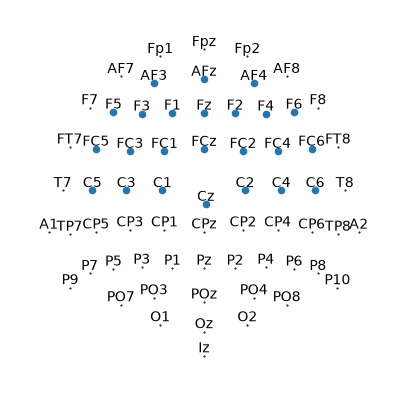

In [6]:
PARAMETERS = {
    'raw': 'ica',
    'group': 'all',
    'samplingrate': 128,
    'data': 'eeg',
    'tstart': -0.100,
    'tstop': 0.600,
}

data = e.load_trfs(1, 'gammatone-8', epoch='clean', **PARAMETERS)
eeg = data['ev']

ROI = [
    'AF3', 'F1', 'F3', 'F5',
    'FC5', 'FC3', 'FC1',
    'C1', 'C3', 'C5',
    'AF4', 'AFz',
    'Fz', 'F2', 'F4', 'F6',
    'FC6', 'FC4', 'FC2', 'FCz',
    'Cz', 'C2', 'C4', 'C6',
]

p = plot.SensorMap(eeg, mark=ROI)

### Display names and colors for attend/ignore/mix

Reused everywhere a plot needs to tell the three streams apart at a
glance - same red/blue/gray convention `cortical_analysis.ipynb` uses for
foreground/background/mixture.

In [7]:
LABELS_ROLE = {'attend': 'Attend', 'ignore': 'Ignore', 'mix': 'Mixture'}
COLORS_ROLE = {'attend': 'red', 'ignore': 'blue', 'mix': '.3'}

### Peak-timing search windows

Named here, once, so every "peak amplitude & timing" cell below points at
one of these instead of a bare number buried in the cell - change a
window in one place and every analysis that uses it picks it up. Onset
and envelope get their own windows; overt/masked onsets get wider ones
since masked onsets are expected to peak later than overt ones (Brodbeck:
roughly 15-50ms slower).

In [8]:
ONSET_POSITIVE_PEAK_WINDOW = (0.040, 0.200)    
ONSET_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)     
ENVELOPE_POSITIVE_PEAK_WINDOW = (0.040, 0.200) 
ENVELOPE_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)
MASKED_POSITIVE_PEAK_WINDOW = (0.040, 0.200)    
MASKED_NEGATIVE_PEAK_WINDOW = (0.040, 0.200)

### Model-comparison helpers

Two comparison syntaxes are used below (see `e.load_model_test`'s own
docstring): **`full_model @ predictor`** (omission - fit `full_model`,
then a null model with just `predictor` removed) for "unique
contribution" analyses, and **`model_a > model_b`** (a *direct* comparison
between two independently-specified, non-nested models) for the
overt/masked-split-vs-plain-onsets and masked-aware-vs-level-aware
comparisons - eelbrain supports this directly in its model-string
grammar, no separate API needed.

Both return the same shape of result: `data` (one row per subject per
model - `'test'`/`'baseline'`), `diff` (one row per subject: the
per-subject improvement score, `test` minus `baseline`, already averaged
over the ROI), and `result` (the mass-univariate significance-test
object). Each condition section below calls these once per analysis, then
uses `data`/`diff`/`result` across the next couple of cells - the topomap
trio, the stat result, and the per-subject swarm plot are deliberately
separate cells so each one's output is easy to find.

Unlike the TRF-fitting helpers further down, these two always call
`e.load_model_test()` themselves rather than reading from an
already-loaded result: a model *comparison* (full vs. null) is its own
derivative, not something that can be read out of a plain `load_trfs()`
fit, so there is no equivalent "load once, reuse" shortcut available here.

In [9]:
def compute_unique_contribution(full_model, predictor, epoch, roi=ROI, metric=METRIC):
    "Omission comparison: does `predictor` uniquely improve on `full_model` with it removed?"
    comparison = f"{full_model} @ {predictor}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result


def compute_direct_comparison(model_a, model_b, epoch, roi=ROI, metric=METRIC):
    "Direct, non-nested comparison: does model_a fit better than model_b?"
    comparison = f"{model_a} > {model_b}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result


def show_topomap_trio(data, diff, result, label, epoch, predictor, metric=METRIC):
    "Group-averaged topomaps: the test model's own fit, the baseline model's own fit, and their significance-masked difference"
    pct = metric == 'ev'
    topo_kwargs = dict(pct=pct, condition=epoch, predictor=predictor, colorbar_side='left', colorbar_label=False, **TOPO_ARGS)
    topomap_with_colorbar(metric, data.sub("model == 'test'"), label=f'{label}: test', **topo_kwargs)
    topomap_with_colorbar(metric, data.sub("model == 'baseline'"), label=f'{label}: baseline', **topo_kwargs)
    # The third panel needs to show the mean r/ev difference (the actual
    # unique contribution), masked by significance - NOT result's own
    # masked_parameter_map() directly, which holds the test's underlying
    # t-values (whatever units the cluster test itself ran on), not the
    # r/ev difference this notebook otherwise reports everywhere else.
    # So: take the real mean difference, and only borrow the *mask* -
    # which sensors were significant - from the test result.
    mean_diff = diff[metric].mean('case')
    significant = numpy.ma.getmaskarray(result.masked_parameter_map(pmin=PMIN).x)
    masked_diff = NDVar(numpy.ma.MaskedArray(mean_diff.x, mask=significant), mean_diff.dims, mean_diff.name, mean_diff.info)
    topomap_with_colorbar(None, masked_diff, label=f'{label}: test - baseline', **topo_kwargs)


def show_subject_swarm(diff, label, epoch, metric=METRIC):
    "One dot per subject: their own ROI-averaged test-minus-baseline score (Brodbeck Fig 3B/4B style)"
    fig, ax = plt.subplots(figsize=(2, 2.5))
    sns.swarmplot(y=diff[f'roi_{metric}'].x, ax=ax, size=5, color='.25')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_ylabel(metric)
    ax.set_xticks([])
    ax.set_title(f'{label} ({epoch})', fontsize=9)
    fig.tight_layout()
    return fig

### TRF-reading and peak-timing helpers

`extract_strf`/`extract_trf` pull one predictor's response out of an
*already-loaded* `load_trfs()` result (`data_full`/`data_masked`, each
loaded exactly once per condition just below) rather than reloading or
refitting - the TRF fit itself is the expensive part of this notebook,
and a model like `FULL_BASE` only ever needs to be fit once per condition
even though a dozen or more cells below each read a different one of its
predictor columns. `add_peak` stays generic (a name and a window in, two
new columns out) so it's the same one function for onsets, envelope,
overt, and masked alike.

In [10]:
def extract_strf(data_full, column, roi=ROI):
    "Group-average (frequency, time) STRF for one predictor column, read from an already-loaded load_trfs() result"
    return data_full[column].mean(sensor=roi).mean('case')


def extract_trf(data_full, column, roi=ROI):
    "Per-subject, ROI-averaged, frequency-summed, smoothed TRF for one predictor column, read from an already-loaded load_trfs() result"
    trf = data_full[column].sum('frequency').mean(sensor=roi)
    ds = data_full['subject',]
    ds['trf_sm'] = resample(trf, 512)
    return ds


def add_peak(ds, name, window, kind='max'):
    "Add `{name}_time`/`{name}_amp`: the location/value of ds['trf_sm']'s peak within `window`"
    segment = ds['trf_sm'].sub(time=window)
    if kind == 'max':
        ds[f'{name}_time'] = segment.argmax('time')
        ds[f'{name}_amp'] = segment.max('time')
    else:
        ds[f'{name}_time'] = segment.argmin('time')
        ds[f'{name}_amp'] = segment.min('time')
    return ds

## Clean speech (single speaker)

In [11]:
# Loaded once here, reused by every STRF/peak/waveform cell below in
# this section - each one just reads a different predictor column out
# of this same fit instead of re-running the (expensive) TRF fit again.
data_full = e.load_trfs('all', FULL_CLEAN, epoch='clean', **PARAMETERS)

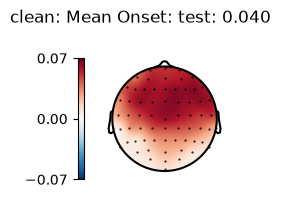

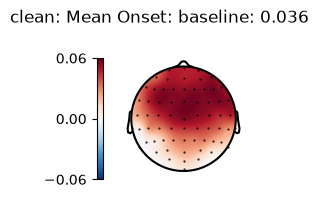

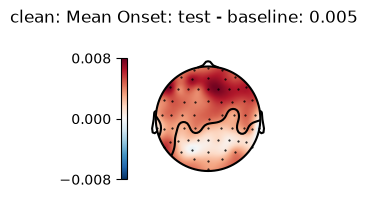

In [12]:
# Onset unique contribution (clean)
# Brodbeck et al. 2020 ran this comparison too: single-speaker onset unique contribution, t = 12.00, p <= .001.
data, diff, result = compute_unique_contribution(FULL_CLEAN, onset(ATTEND), 'clean')
show_topomap_trio(data, diff, result, 'Onset', 'clean', onset(ATTEND))

In [13]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset (clean): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .002>

Onset (clean): ROI unique contribution t(12) = 2.680, p = 0.0100


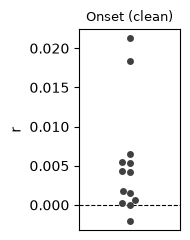

In [14]:
p = show_subject_swarm(diff, 'Onset', 'clean')

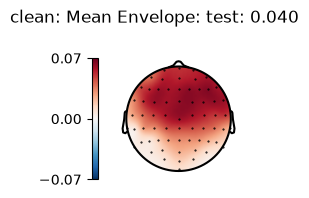

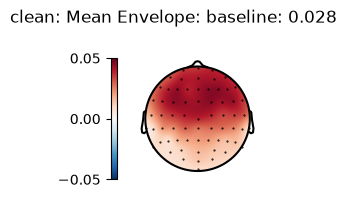

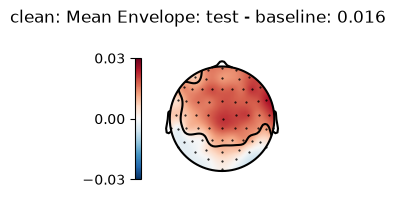

In [15]:
# Envelope unique contribution (clean)
# Brodbeck et al. 2020 ran this comparison too: single-speaker envelope unique contribution, t = 9.39, p <= .001.
data, diff, result = compute_unique_contribution(FULL_CLEAN, envelope(ATTEND), 'clean')
show_topomap_trio(data, diff, result, 'Envelope', 'clean', envelope(ATTEND))

In [16]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope (clean): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .008>

Envelope (clean): ROI unique contribution t(12) = 2.962, p = 0.0059


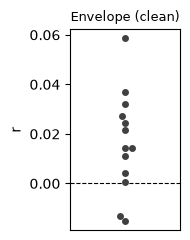

In [17]:
p = show_subject_swarm(diff, 'Envelope', 'clean')

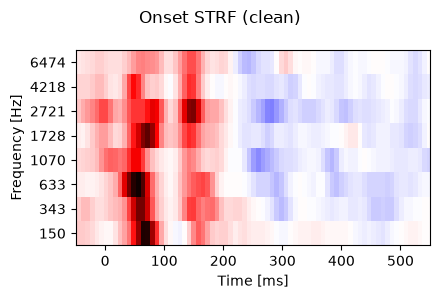

In [18]:
# Onset STRF (clean)
strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array(strf * 1e3, title='Onset STRF (clean)', xlim=(-0.050, 0.550))

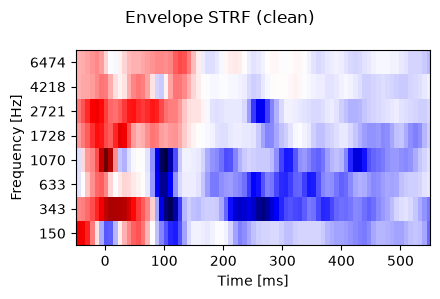

In [19]:
# Envelope STRF (clean)
strf = extract_strf(data_full, 'gammatone_8')
p = plot.Array(strf * 1e3, title='Envelope STRF (clean)', xlim=(-0.050, 0.550))

In [20]:
# Onset peak amplitude & timing (clean)
# Brodbeck et al. 2020 ran this comparison too: onset STRF positive peak ~65ms, negative peak ~126ms.
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset (clean) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset (clean) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset (clean) positive peak: 88 ms, amp 0.003823
Onset (clean) negative peak: 136 ms, amp -0.0001337


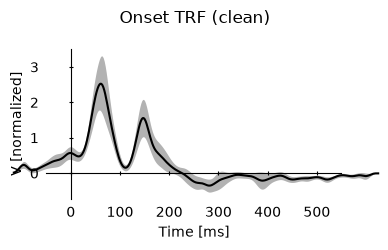

In [21]:
# The TRF waveform the peaks above were measured from - same
# smoothed, ROI-averaged, frequency-summed response as 'data'.
p = plot.UTSStat('trf_sm*1e3', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset TRF (clean)')

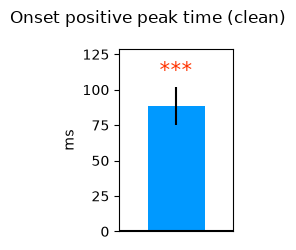

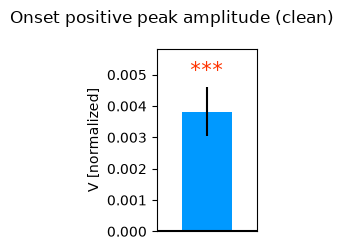

In [22]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset positive peak time (clean)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset positive peak amplitude (clean)')

In [23]:
# Envelope peak amplitude & timing (clean)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope (clean) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope (clean) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope (clean) positive peak: 73 ms, amp 0.001839
Envelope (clean) negative peak: 156 ms, amp -0.002373


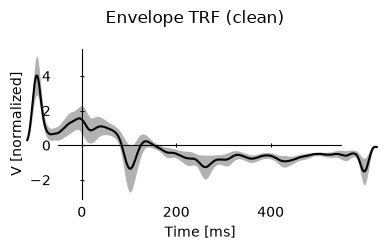

In [24]:
# The TRF waveform the peaks above were measured from - same
# smoothed, ROI-averaged, frequency-summed response as 'data'.
p = plot.UTSStat('trf_sm*1e3', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope TRF (clean)')

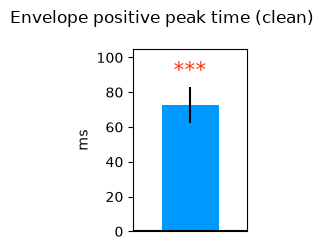

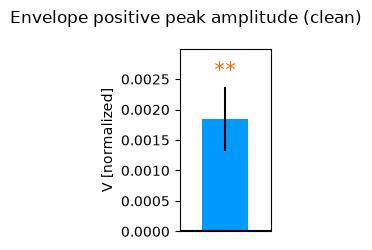

In [25]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope positive peak time (clean)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope positive peak amplitude (clean)')

## Diotic

In [26]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='diotic', **PARAMETERS)

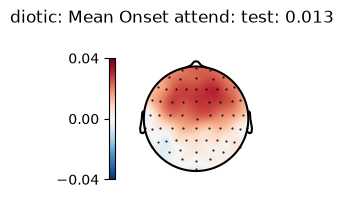

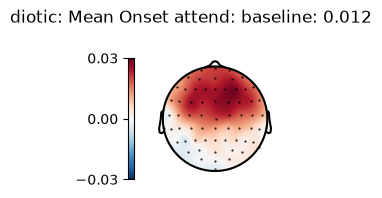

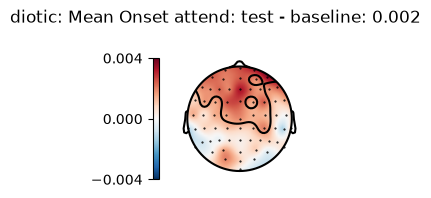

In [27]:
# Onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Onset attend', 'diotic', onset(ATTEND))

In [28]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p < .001>

Onset attend (diotic): ROI unique contribution t(12) = 2.904, p = 0.0066


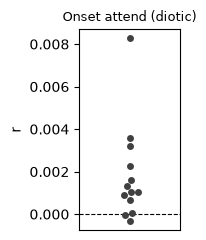

In [29]:
p = show_subject_swarm(diff, 'Onset attend', 'diotic')

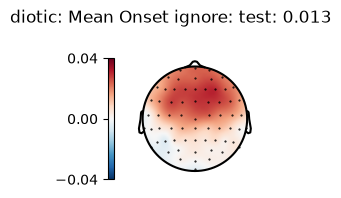

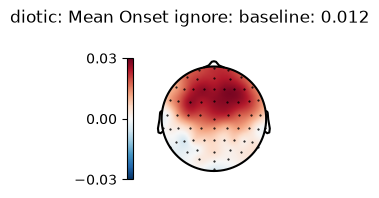

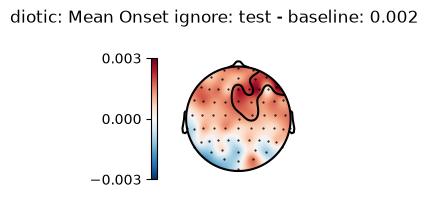

In [30]:
# Onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Onset ignore', 'diotic', onset(IGNORE))

In [31]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .038>

Onset ignore (diotic): ROI unique contribution t(12) = 1.880, p = 0.0423


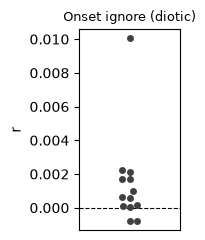

In [32]:
p = show_subject_swarm(diff, 'Onset ignore', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


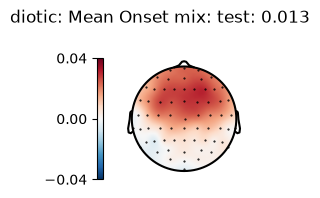

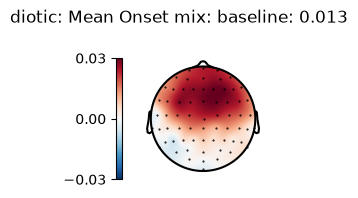

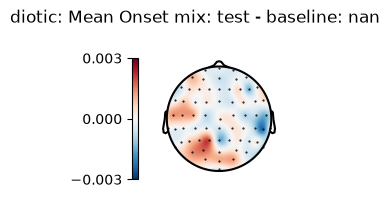

In [33]:
# Onset mix unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'diotic')
show_topomap_trio(data, diff, result, 'Onset mix', 'diotic', onset(MIX))

In [34]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .336>

Onset mix (diotic): ROI unique contribution t(12) = -0.048, p = 0.5187


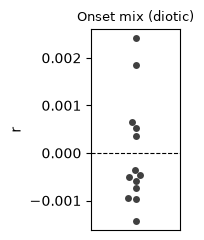

In [35]:
p = show_subject_swarm(diff, 'Onset mix', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


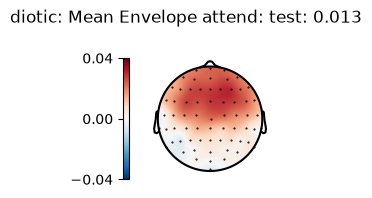

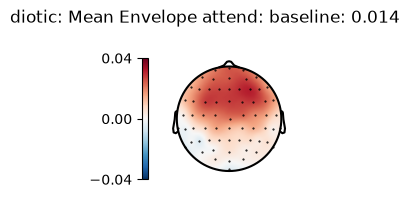

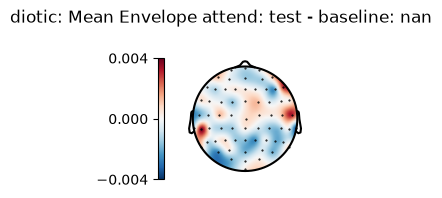

In [36]:
# Envelope attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope attend', 'diotic', envelope(ATTEND))

In [37]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Envelope attend (diotic): ROI unique contribution t(12) = -0.170, p = 0.5660


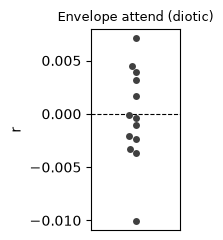

In [38]:
p = show_subject_swarm(diff, 'Envelope attend', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


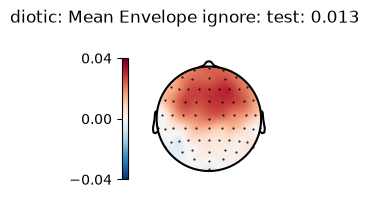

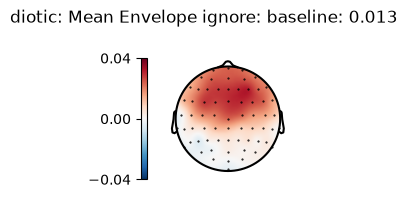

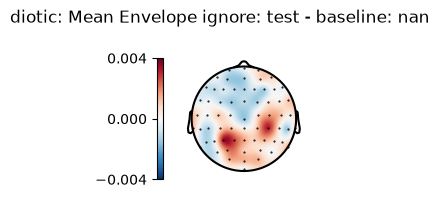

In [39]:
# Envelope ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'diotic', envelope(IGNORE))

In [40]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 2 clusters, p = .181>

Envelope ignore (diotic): ROI unique contribution t(12) = -0.419, p = 0.6589


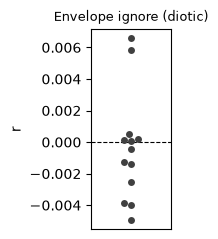

In [41]:
p = show_subject_swarm(diff, 'Envelope ignore', 'diotic')

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


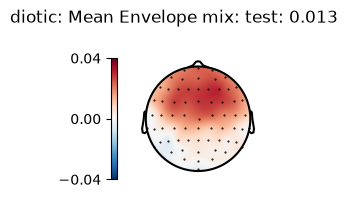

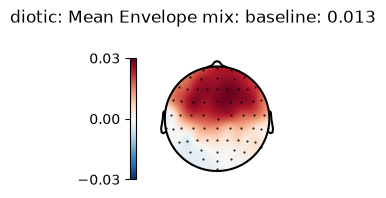

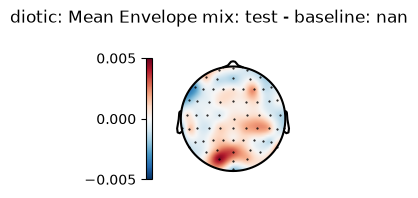

In [42]:
# Envelope mix unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'diotic')
show_topomap_trio(data, diff, result, 'Envelope mix', 'diotic', envelope(MIX))

In [43]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .482>

Envelope mix (diotic): ROI unique contribution t(12) = -0.003, p = 0.5013


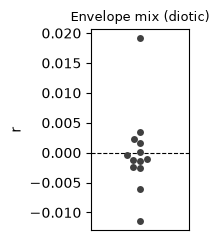

In [44]:
p = show_subject_swarm(diff, 'Envelope mix', 'diotic')

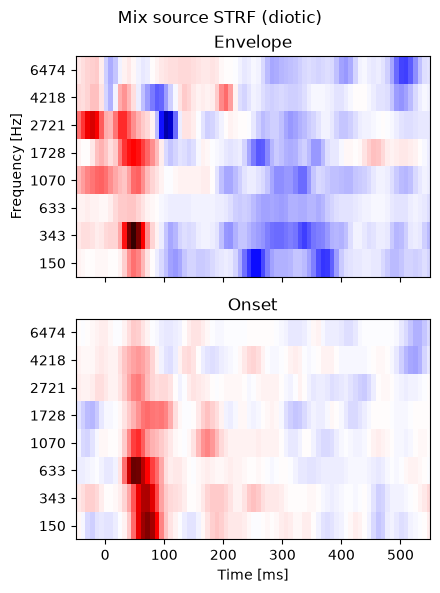

In [45]:
# Mix source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (diotic)', xlim=(-0.050, 0.550))

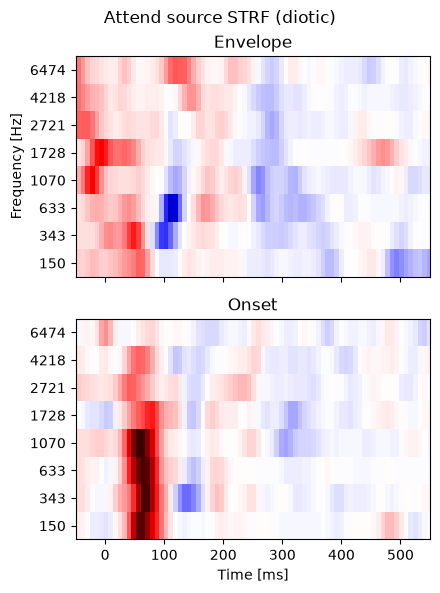

In [46]:
# Attend source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (diotic)', xlim=(-0.050, 0.550))

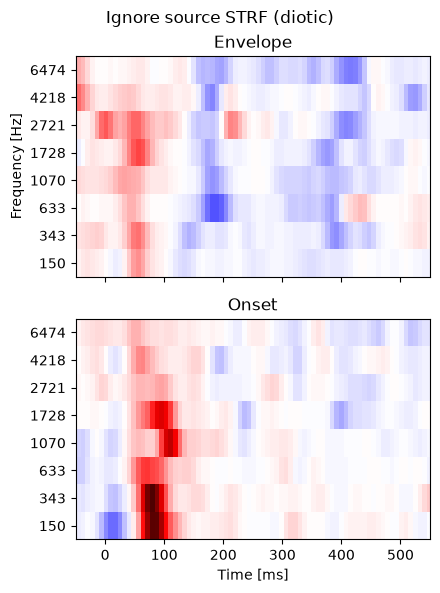

In [47]:
# Ignore source STRF: envelope + onset (diotic)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (diotic)', xlim=(-0.050, 0.550))

In [48]:
# Onset attend peak amplitude & timing (diotic)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset attend (diotic) positive peak: 77 ms, amp 0.002395
Onset attend (diotic) negative peak: 142 ms, amp -0.0004422


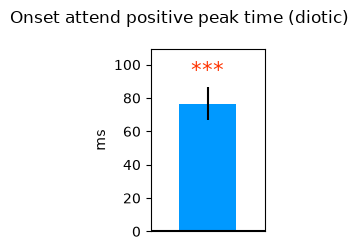

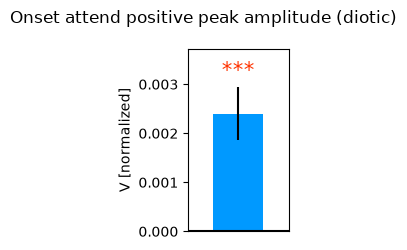

In [49]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak amplitude (diotic)')

In [50]:
# Onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset ignore (diotic) positive peak: 83 ms, amp 0.001875
Onset ignore (diotic) negative peak: 149 ms, amp -0.0001174


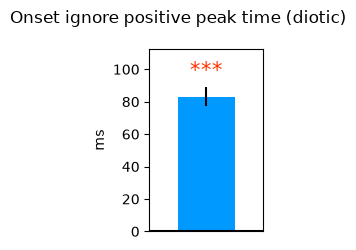

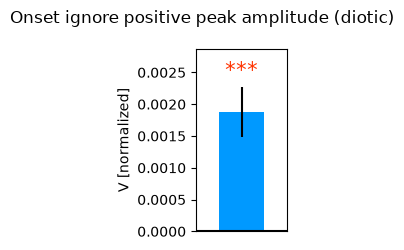

In [51]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak amplitude (diotic)')

In [52]:
# Onset mix peak amplitude & timing (diotic)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Onset mix (diotic) positive peak: 68 ms, amp 0.001748
Onset mix (diotic) negative peak: 125 ms, amp -0.0001259


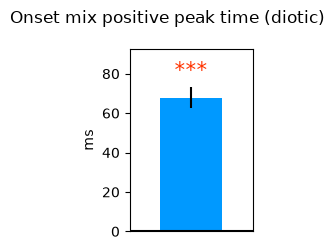

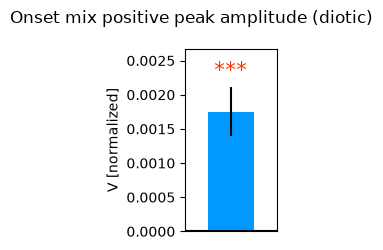

In [53]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak amplitude (diotic)')

In [54]:
# Envelope attend peak amplitude & timing (diotic)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope attend (diotic) positive peak: 94 ms, amp 0.0008674
Envelope attend (diotic) negative peak: 143 ms, amp -0.0006356


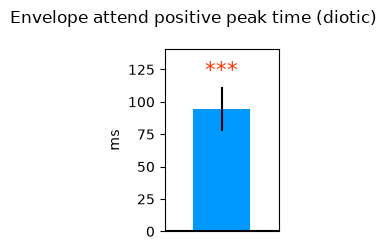

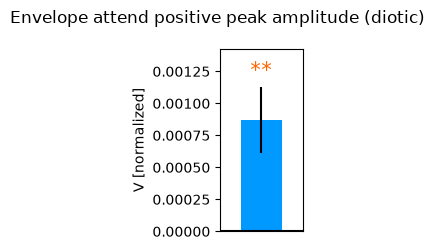

In [55]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak amplitude (diotic)')

In [56]:
# Envelope ignore peak amplitude & timing (diotic)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope ignore (diotic) positive peak: 67 ms, amp 0.0007042
Envelope ignore (diotic) negative peak: 166 ms, amp -0.0006253


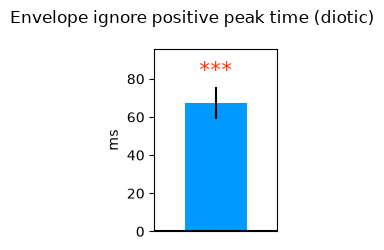

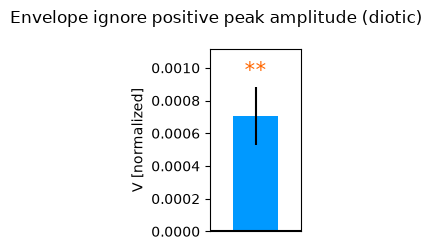

In [57]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak amplitude (diotic)')

In [58]:
# Envelope mix peak amplitude & timing (diotic)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Envelope mix (diotic) positive peak: 84 ms, amp 0.001394
Envelope mix (diotic) negative peak: 153 ms, amp -0.0007725


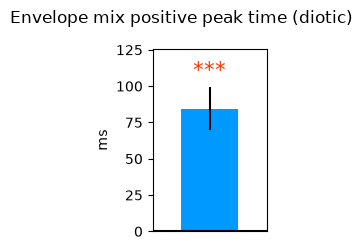

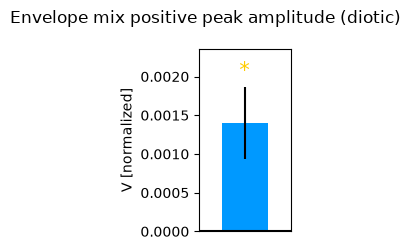

In [59]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak amplitude (diotic)')

In [60]:
# Onset peak comparison across mix, attend, and ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

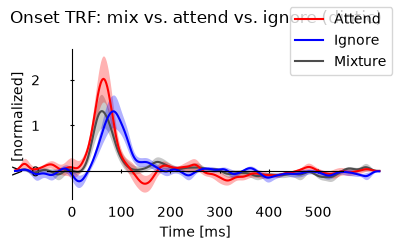

In [61]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (diotic)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [62]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.68 p = .511,t12 = -1.64 p = .126
attend,,t12 = -0.56 p = .583


,attend,ignore
mix,t12 = -1.02 p = .330,t12 = -1.13 p = .280
attend,,t12 = -0.30 p = .769


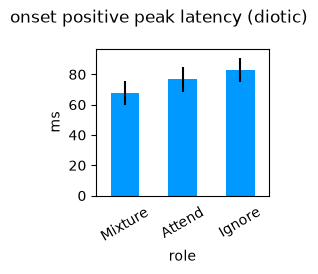

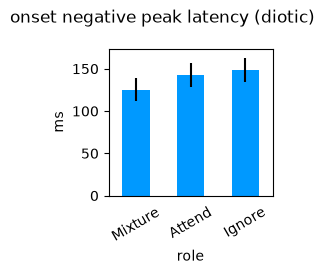

In [63]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [64]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -1.27 p = .227,t12 = -0.36 p = .726
attend,,t12 = 0.90 p = .386


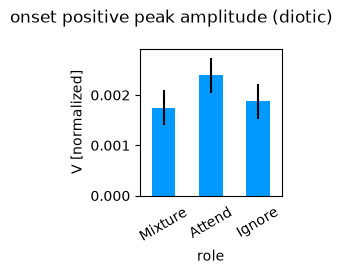

In [65]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (diotic)')
p.set_xtick_rotation(30)

In [66]:
# Envelope peak comparison across mix, attend, and ignore (diotic)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

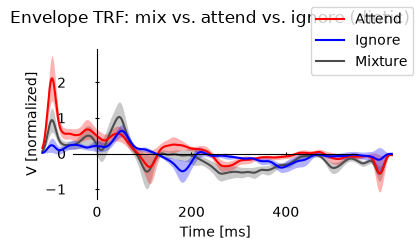

In [67]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (diotic)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [68]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = -0.42 p = .685,t12 = 1.34 p = .205
attend,,t12 = 1.62 p = .132


,attend,ignore
mix,t12 = 0.71 p = .489,t12 = -0.87 p = .400
attend,,t12 = -1.36 p = .198


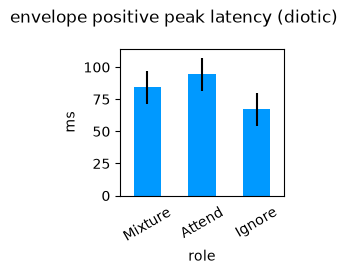

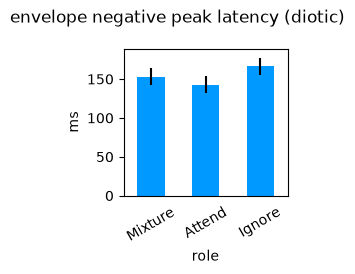

In [69]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (diotic)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (diotic)')
p.set_xtick_rotation(30)

In [70]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))

,attend,ignore
mix,t12 = 1.28 p = .225,t12 = 1.63 p = .130
attend,,t12 = 0.57 p = .579


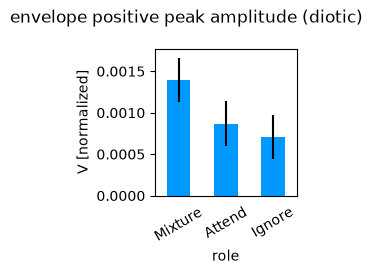

In [71]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (diotic)')
p.set_xtick_rotation(30)

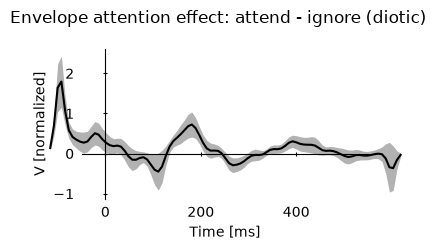

In [72]:
# Envelope attention effect: attend - ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (diotic)')

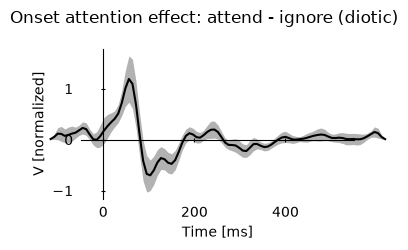

In [73]:
# Onset attention effect: attend - ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (diotic)')

## Diotic (overt onsets)

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


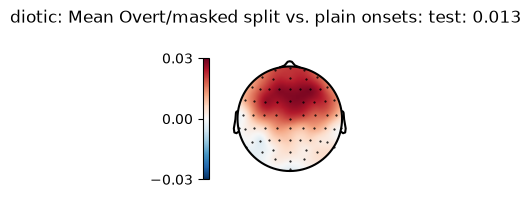

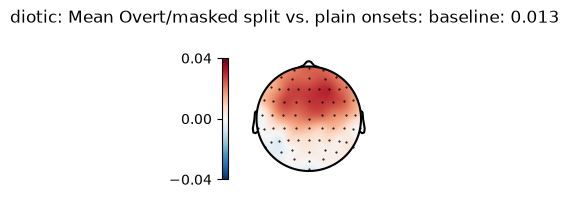

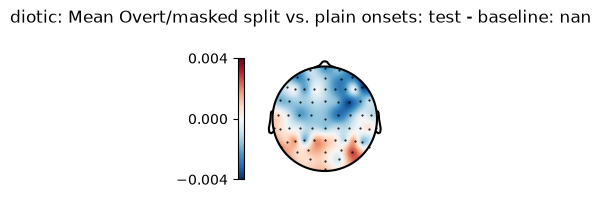

In [74]:
# Overt/masked split vs. plain onsets (diotic)
# overt/masked = the split of an onset predictor into its overt and masked half.
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.

# FULL_BASE   = Eatt + Oatt + Eign + Oign + Emix + Omix
# FULL_MASKED = Eatt + Oatt_overt + Oatt_masked + Eign + Oign_overt + Oign_masked + Emix + Omix
#
# Comparison: FULL_MASKED > FULL_BASE
#   (does replacing Oatt/Oign with their overt+masked split improve the
#   fit over the plain-onset model?)
#
# Full predictor names:
# FULL_MASKED (test model):
#   gammatone-8 + gammatone-on-overt-8 + gammatone-on-masked-8
#   + bg~gammatone-8 + bg~gammatone-on-overt-8 + bg~gammatone-on-masked-8
#   + mix~gammatone-8 + mix~gammatone-on-8
#
# FULL_BASE (baseline model):
#   gammatone-8 + gammatone-on-8
#   + bg~gammatone-8 + bg~gammatone-on-8
#   + mix~gammatone-8 + mix~gammatone-on-8

data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'diotic')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'diotic', None)

In [75]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (diotic): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, no clusters>

Overt/masked split vs. plain onsets (diotic): ROI model comparison t(12) = -1.887, p = 0.9582


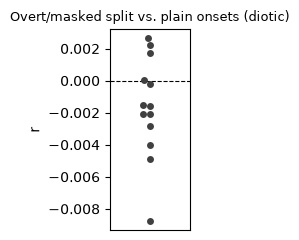

In [76]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'diotic')

In [77]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='diotic', **PARAMETERS)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


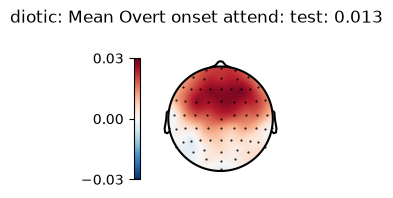

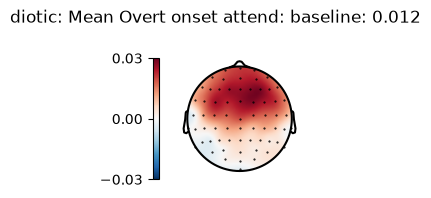

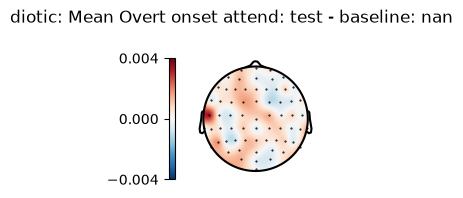

In [78]:
# Overt onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'diotic', overt_onset(ATTEND))

In [79]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 5 clusters, p = .151>

Overt onset attend (diotic): ROI unique contribution t(12) = 0.932, p = 0.1849


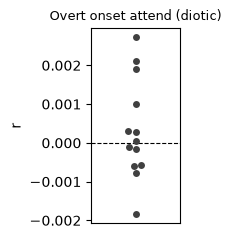

In [80]:
p = show_subject_swarm(diff, 'Overt onset attend', 'diotic')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


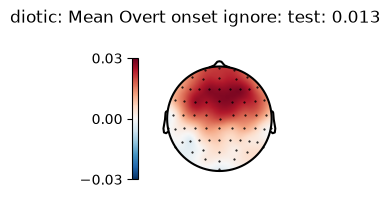

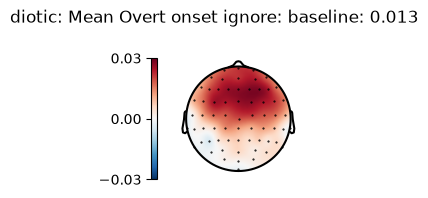

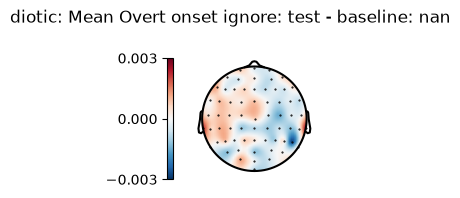

In [81]:
# Overt onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'diotic', overt_onset(IGNORE))

In [82]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .561>

Overt onset ignore (diotic): ROI unique contribution t(12) = -0.032, p = 0.5126


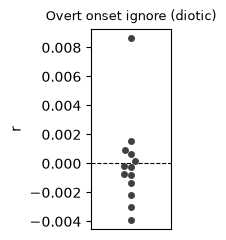

In [83]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'diotic')

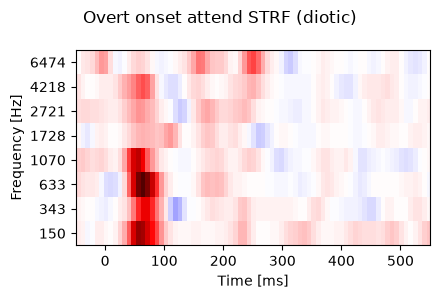

In [84]:
# Overt onset attend STRF (diotic)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (diotic)', xlim=(-0.050, 0.550))

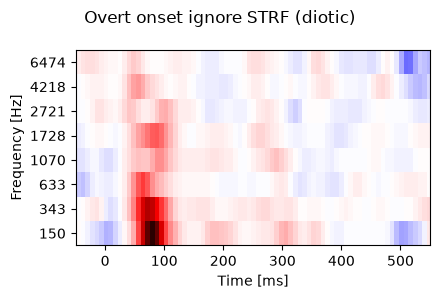

In [85]:
# Overt onset ignore STRF (diotic)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (diotic)', xlim=(-0.050, 0.550))

In [86]:
# Overt onset attend peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset attend (diotic) positive peak: 82 ms, amp 0.001735
Overt onset attend (diotic) negative peak: 132 ms, amp -0.0002131


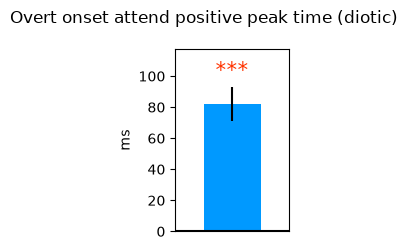

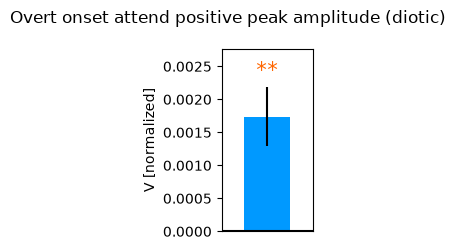

In [87]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak amplitude (diotic)')

In [88]:
# Overt onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Overt onset ignore (diotic) positive peak: 88 ms, amp 0.001345
Overt onset ignore (diotic) negative peak: 155 ms, amp -7.801e-05


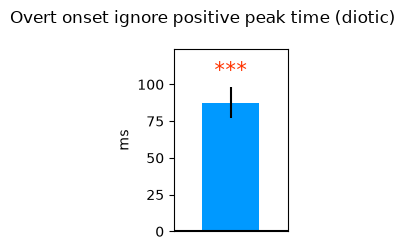

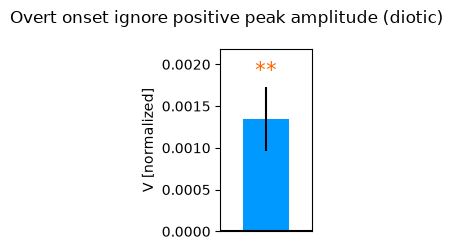

In [89]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak amplitude (diotic)')

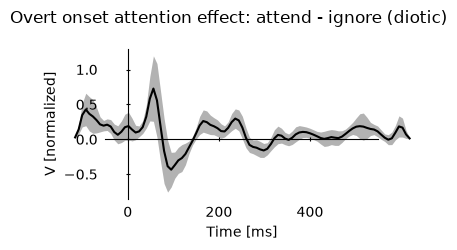

In [90]:
# Overt onset attention effect: attend - ignore (diotic)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (diotic)')

## Diotic (masked onset)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


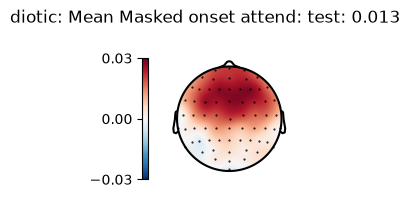

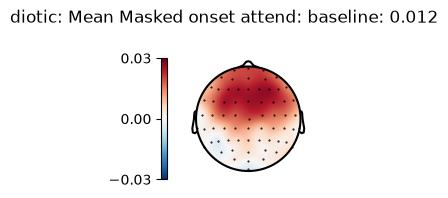

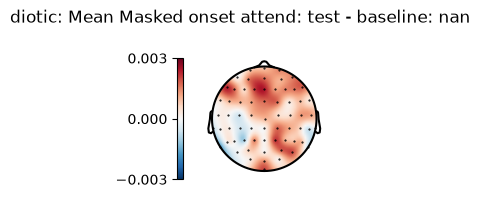

In [91]:
# Masked onset attend unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'diotic')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'diotic', masked_onset(ATTEND))

In [92]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .153>

Masked onset attend (diotic): ROI unique contribution t(12) = 1.620, p = 0.0656


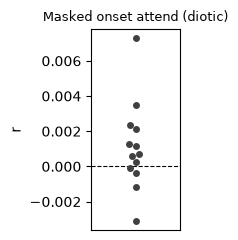

In [93]:
p = show_subject_swarm(diff, 'Masked onset attend', 'diotic')

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


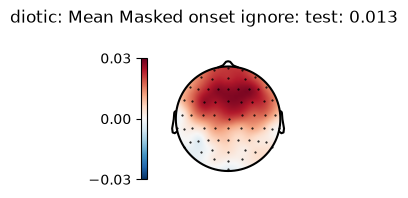

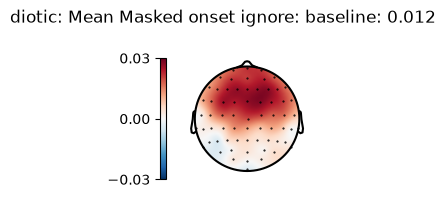

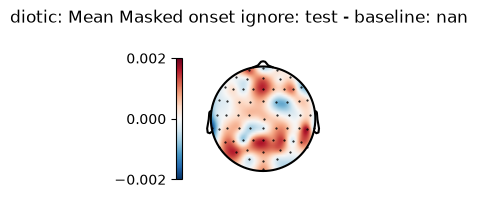

In [94]:
# Masked onset ignore unique contribution (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'diotic')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'diotic', masked_onset(IGNORE))

In [95]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (diotic): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 3 clusters, p = .417>

Masked onset ignore (diotic): ROI unique contribution t(12) = 0.959, p = 0.1783


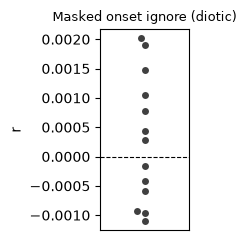

In [96]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'diotic')

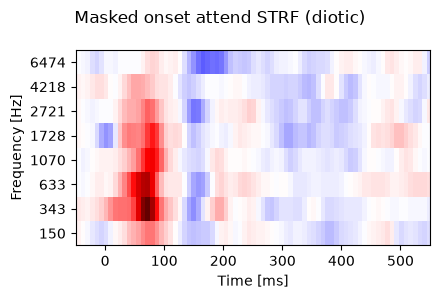

In [97]:
# Masked onset attend STRF (diotic)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (diotic)', xlim=(-0.050, 0.550))

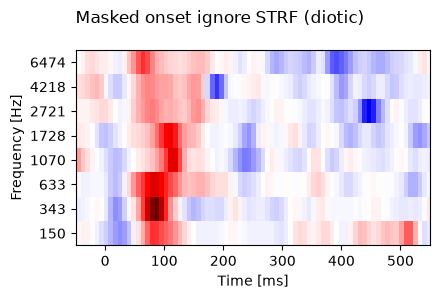

In [98]:
# Masked onset ignore STRF (diotic)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (diotic)', xlim=(-0.050, 0.550))

In [99]:
# Masked onset attend peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset attend (diotic) positive peak: 90 ms, amp 0.001303
Masked onset attend (diotic) negative peak: 161 ms, amp -0.0005202


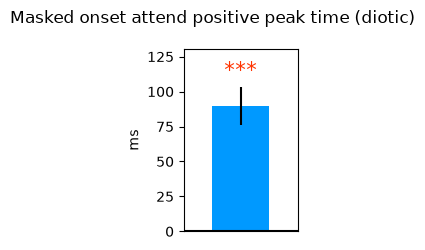

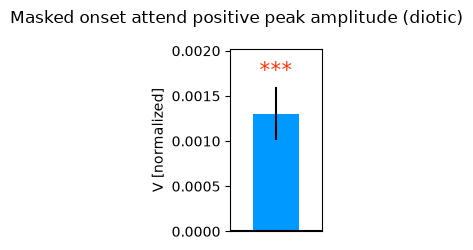

In [100]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak amplitude (diotic)')

In [101]:
# Masked onset ignore peak amplitude & timing (diotic)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (diotic) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (diotic) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

Masked onset ignore (diotic) positive peak: 89 ms, amp 0.001172
Masked onset ignore (diotic) negative peak: 137 ms, amp -0.0002829


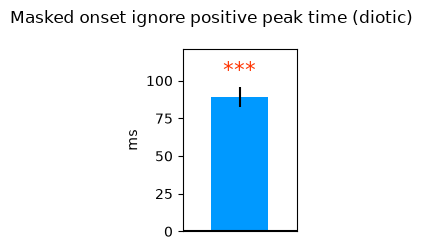

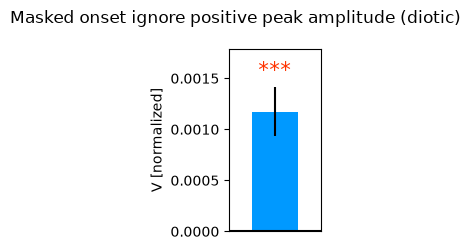

In [102]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak time (diotic)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak amplitude (diotic)')

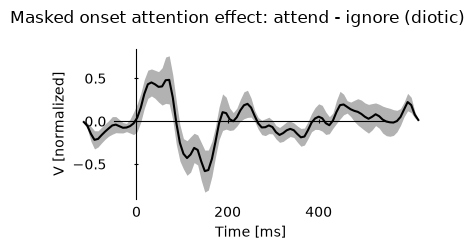

In [103]:
# Masked onset attention effect: attend - ignore (diotic)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (diotic)')

In [104]:
# Overt vs. masked peak comparison, attend (diotic)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [105]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

,masked
overt,t12 = -0.60 p = .562


,masked
overt,t12 = -2.18* p = .050


In [106]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.91 p = .379


In [107]:
# Overt vs. masked peak comparison, ignore (diotic)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [108]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

,masked
overt,t12 = -0.12 p = .903


,masked
overt,t12 = 0.70 p = .495


In [109]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))

,masked
overt,t12 = 0.46 p = .650


In [110]:
# Stream x masking interaction on peak amplitude (diotic)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (diotic)'))

<ANOVA: positive_amp ~ stream + masking + stream x masking + subject + stream x subject + masking x subject + stream x masking x subject
  
  stream x masking interaction (diotic)
  
                       SS   df     MS   MS(denom)   df(denom)         F      p
  ----------------------------------------------------------------------------
  stream             0.00    1   0.00        0.00          12   0.56      .467
  masking            0.00    1   0.00        0.00          12   1.28      .280
  stream x masking   0.00    1   0.00        0.00          12   0.15      .704
  ----------------------------------------------------------------------------
  Total              0.00   51
>

## Diotic (intensity-level control)

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

/Users/joshuaighalo/Github Repositories/cocktail-cortical/analysis/experiment.py:957: UserWarning: Warning: converting a masked element to nan.
  mean_value = float(data.mean())


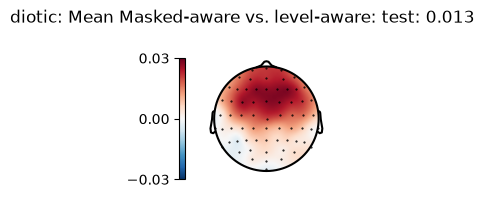

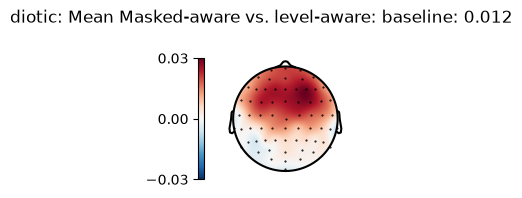

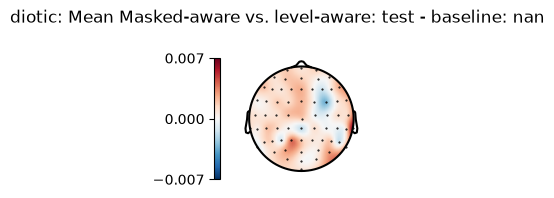

In [111]:
# Masked-aware vs. level-aware (diotic)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'diotic')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'diotic', None)

In [112]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (diotic): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

<TTestRelated 'r', 'model', 'test', 'baseline', 'subject' (n=13), tail=1, samples=8191, pmin=0.05, 1 clusters, p = .399>

Masked-aware vs. level-aware (diotic): ROI model comparison t(12) = 0.468, p = 0.3242


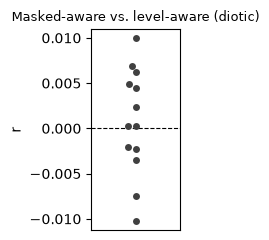

In [113]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'diotic')

## Dichotic Left

In [114]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='dichotic-left', **PARAMETERS)

KeyboardInterrupt: 

In [ ]:
# Onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset attend', 'dichotic-left', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'dichotic-left')

In [ ]:
# Onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset ignore', 'dichotic-left', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'dichotic-left')

In [ ]:
# Onset mix unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Onset mix', 'dichotic-left', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'dichotic-left')

In [ ]:
# Envelope attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope attend', 'dichotic-left', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'dichotic-left')

In [ ]:
# Envelope ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'dichotic-left', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'dichotic-left')

In [ ]:
# Envelope mix unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Envelope mix', 'dichotic-left', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'dichotic-left')

In [ ]:
# Mix source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Attend source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Ignore source STRF: envelope + onset (dichotic-left)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak amplitude (dichotic-left)')

In [ ]:
# Onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak amplitude (dichotic-left)')

In [ ]:
# Onset mix peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak amplitude (dichotic-left)')

In [ ]:
# Envelope attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak amplitude (dichotic-left)')

In [ ]:
# Envelope ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak amplitude (dichotic-left)')

In [ ]:
# Envelope mix peak amplitude & timing (dichotic-left)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak amplitude (dichotic-left)')

In [ ]:
# Onset peak comparison across mix, attend, and ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (dichotic-left)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (dichotic-left)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (dichotic-left)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (dichotic-left)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (dichotic-left)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope attention effect: attend - ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (dichotic-left)')

In [ ]:
# Onset attention effect: attend - ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (dichotic-left)')

## Dichotic Left (overt onsets)

In [ ]:
# Overt/masked split vs. plain onsets (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'dichotic-left', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (dichotic-left): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'dichotic-left')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='dichotic-left', **PARAMETERS)

In [ ]:
# Overt onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'dichotic-left', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'dichotic-left')

In [ ]:
# Overt onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'dichotic-left', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'dichotic-left')

In [ ]:
# Overt onset attend STRF (dichotic-left)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset ignore STRF (dichotic-left)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak amplitude (dichotic-left)')

In [ ]:
# Overt onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak amplitude (dichotic-left)')

In [ ]:
# Overt onset attention effect: attend - ignore (dichotic-left)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (dichotic-left)')

## Dichotic Left (masked onset)

In [ ]:
# Masked onset attend unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'dichotic-left', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'dichotic-left')

In [ ]:
# Masked onset ignore unique contribution (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'dichotic-left', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (dichotic-left): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'dichotic-left')

In [ ]:
# Masked onset attend STRF (dichotic-left)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset ignore STRF (dichotic-left)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (dichotic-left)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak amplitude (dichotic-left)')

In [ ]:
# Masked onset ignore peak amplitude & timing (dichotic-left)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (dichotic-left) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (dichotic-left) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak time (dichotic-left)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak amplitude (dichotic-left)')

In [ ]:
# Masked onset attention effect: attend - ignore (dichotic-left)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (dichotic-left)')

In [ ]:
# Overt vs. masked peak comparison, attend (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))

In [ ]:
# Overt vs. masked peak comparison, ignore (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))

In [ ]:
# Stream x masking interaction on peak amplitude (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (dichotic-left)'))

## Dichotic Left (intensity-level control)

In [ ]:
# Masked-aware vs. level-aware (dichotic-left)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'dichotic-left')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'dichotic-left', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (dichotic-left): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'dichotic-left')

## Dichotic Right

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='dichotic-right', **PARAMETERS)

In [ ]:
# Onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset attend', 'dichotic-right', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'dichotic-right')

In [ ]:
# Onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset ignore', 'dichotic-right', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'dichotic-right')

In [ ]:
# Onset mix unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Onset mix', 'dichotic-right', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'dichotic-right')

In [ ]:
# Envelope attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope attend', 'dichotic-right', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'dichotic-right')

In [ ]:
# Envelope ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'dichotic-right', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'dichotic-right')

In [ ]:
# Envelope mix unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Envelope mix', 'dichotic-right', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'dichotic-right')

In [ ]:
# Mix source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Attend source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Ignore source STRF: envelope + onset (dichotic-right)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak amplitude (dichotic-right)')

In [ ]:
# Onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak amplitude (dichotic-right)')

In [ ]:
# Onset mix peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak amplitude (dichotic-right)')

In [ ]:
# Envelope attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak amplitude (dichotic-right)')

In [ ]:
# Envelope ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak amplitude (dichotic-right)')

In [ ]:
# Envelope mix peak amplitude & timing (dichotic-right)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak amplitude (dichotic-right)')

In [ ]:
# Onset peak comparison across mix, attend, and ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (dichotic-right)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (dichotic-right)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (dichotic-right)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (dichotic-right)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (dichotic-right)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope attention effect: attend - ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (dichotic-right)')

In [ ]:
# Onset attention effect: attend - ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (dichotic-right)')

## Dichotic Right (overt onsets)

In [ ]:
# Overt/masked split vs. plain onsets (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'dichotic-right', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (dichotic-right): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'dichotic-right')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='dichotic-right', **PARAMETERS)

In [ ]:
# Overt onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'dichotic-right', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'dichotic-right')

In [ ]:
# Overt onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'dichotic-right', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'dichotic-right')

In [ ]:
# Overt onset attend STRF (dichotic-right)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset ignore STRF (dichotic-right)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak amplitude (dichotic-right)')

In [ ]:
# Overt onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak amplitude (dichotic-right)')

In [ ]:
# Overt onset attention effect: attend - ignore (dichotic-right)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (dichotic-right)')

## Dichotic Right (masked onset)

In [ ]:
# Masked onset attend unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'dichotic-right', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'dichotic-right')

In [ ]:
# Masked onset ignore unique contribution (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'dichotic-right', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (dichotic-right): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'dichotic-right')

In [ ]:
# Masked onset attend STRF (dichotic-right)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset ignore STRF (dichotic-right)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (dichotic-right)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak amplitude (dichotic-right)')

In [ ]:
# Masked onset ignore peak amplitude & timing (dichotic-right)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (dichotic-right) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (dichotic-right) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak time (dichotic-right)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak amplitude (dichotic-right)')

In [ ]:
# Masked onset attention effect: attend - ignore (dichotic-right)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (dichotic-right)')

In [ ]:
# Overt vs. masked peak comparison, attend (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))

In [ ]:
# Overt vs. masked peak comparison, ignore (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))

In [ ]:
# Stream x masking interaction on peak amplitude (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (dichotic-right)'))

## Dichotic Right (intensity-level control)

In [ ]:
# Masked-aware vs. level-aware (dichotic-right)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'dichotic-right')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'dichotic-right', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (dichotic-right): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'dichotic-right')

## Binaural

In [ ]:
# Loaded once here, reused by every unique-contribution/STRF/peak/
# waveform/attention-effect cell in this section - each one just
# reads a different predictor column out of this same fit instead
# of re-running the (expensive) TRF fit on FULL_BASE again.
data_full = e.load_trfs('all', FULL_BASE, epoch='binaural', **PARAMETERS)

In [ ]:
# Onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended onsets unique contribution, t = 6.32, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Onset attend', 'binaural', onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset attend', 'binaural')

In [ ]:
# Onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored onsets unique contribution, t = 6.70, p < .001 - the ignored speaker is tracked separately.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Onset ignore', 'binaural', onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset ignore', 'binaural')

In [ ]:
# Onset mix unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: mixture onsets unique contribution, t = 8.61, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, onset(MIX), 'binaural')
show_topomap_trio(data, diff, result, 'Onset mix', 'binaural', onset(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Onset mix (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Onset mix', 'binaural')

In [ ]:
# Envelope attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended envelope unique contribution, t = 7.37, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope attend', 'binaural', envelope(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope attend', 'binaural')

In [ ]:
# Envelope ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored envelope unique contribution, t = 6.28, p < .001 - the ignored speaker's envelope is tracked separately too.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope ignore', 'binaural', envelope(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope ignore', 'binaural')

In [ ]:
# Envelope mix unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: mixture envelope unique contribution, t = 5.70, p < .001.
data, diff, result = compute_unique_contribution(FULL_BASE, envelope(MIX), 'binaural')
show_topomap_trio(data, diff, result, 'Envelope mix', 'binaural', envelope(MIX))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Envelope mix (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Envelope mix', 'binaural')

In [ ]:
# Mix source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'mix_gammatone_8')
onset_strf = extract_strf(data_full, 'mix_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Mix source STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Attend source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'gammatone_8')
onset_strf = extract_strf(data_full, 'gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Attend source STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Ignore source STRF: envelope + onset (binaural)
envelope_strf = extract_strf(data_full, 'bg_gammatone_8')
onset_strf = extract_strf(data_full, 'bg_gammatone_on_8')
p = plot.Array([envelope_strf * 1e3, onset_strf * 1e3], axtitle=['Envelope', 'Onset'],
                title='Ignore source STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Onset attend peak amplitude & timing (binaural)
data = extract_trf(data_full, 'gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset attend positive peak amplitude (binaural)')

In [ ]:
# Onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_full, 'bg_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset ignore positive peak amplitude (binaural)')

In [ ]:
# Onset mix peak amplitude & timing (binaural)
data = extract_trf(data_full, 'mix_gammatone_on_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Onset mix (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Onset mix (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Onset mix positive peak amplitude (binaural)')

In [ ]:
# Envelope attend peak amplitude & timing (binaural)
data = extract_trf(data_full, 'gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope attend positive peak amplitude (binaural)')

In [ ]:
# Envelope ignore peak amplitude & timing (binaural)
data = extract_trf(data_full, 'bg_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope ignore positive peak amplitude (binaural)')

In [ ]:
# Envelope mix peak amplitude & timing (binaural)
data = extract_trf(data_full, 'mix_gammatone_8')
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Envelope mix (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Envelope mix (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Envelope mix positive peak amplitude (binaural)')

In [ ]:
# Onset peak comparison across mix, attend, and ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: positive peak latency mixture 72ms, attended 81ms (t=4.47,p<.001), ignored 89ms (t=6.92,p<.001); negative peak latency mixture 138ms, attended 150ms (t=3.20,p=.004); positive peak amplitude bigger for mixture than attended (t=8.41) or ignored (t=7.66).
dss = []
for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The onset TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Onset TRF: mix vs. attend vs. ignore (binaural)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='onset positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='onset negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='onset positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='onset positive peak amplitude (binaural)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak comparison across mix, attend, and ignore (binaural)
dss = []
for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
    ds = extract_trf(data_full, column)
    ds[:, 'role'] = role_name
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
# The envelope TRF waveform mix/attend/ignore were each just measured
# from, overlaid so their shape and relative timing are visible
# directly, not just as extracted peak numbers below.
p = plot.UTSStat('trf_sm*1e3', 'role', data=data, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550),
                  title='Envelope TRF: mix vs. attend vs. ignore (binaural)', labels=LABELS_ROLE, colors=COLORS_ROLE)

In [ ]:
display(test.pairwise('positive_time', 'role', match='subject', data=data, corr=False, title='envelope positive peak latency: mix vs. attend vs. ignore'))
display(test.pairwise('negative_time', 'role', match='subject', data=data, corr=False, title='envelope negative peak latency: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak latency (binaural)')
p.set_xtick_rotation(30)
p = plot.Barplot('negative_time', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope negative peak latency (binaural)')
p.set_xtick_rotation(30)

In [ ]:
display(test.pairwise('positive_amp', 'role', match='subject', data=data, corr=False, title='envelope positive peak amplitude: mix vs. attend vs. ignore'))

In [ ]:
p = plot.Barplot('positive_amp', 'role', match='subject', data=data, h=2.5, w=2.5, labels=LABELS_ROLE, corr=False, title='envelope positive peak amplitude (binaural)')
p.set_xtick_rotation(30)

In [ ]:
# Envelope attention effect: attend - ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: envelope attention-effect difference wave: negative bump ~100ms, positive bump ~200ms, starting almost immediately.
attend_trf = data_full['gammatone_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Envelope attention effect: attend - ignore (binaural)')

In [ ]:
# Onset attention effect: attend - ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: onset attention effect appears later than the envelope's, once the masked-onset response develops (see the masked-onset section below).
attend_trf = data_full['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_full['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Onset attention effect: attend - ignore (binaural)')

## Binaural (overt onsets)

In [ ]:
# Overt/masked split vs. plain onsets (binaural)
# Brodbeck et al. 2020 ran this comparison too: splitting onsets into overt/masked significantly improved the model overall, t = 6.81, p < .001.
data, diff, result = compute_direct_comparison(FULL_MASKED, FULL_BASE, 'binaural')
show_topomap_trio(data, diff, result, 'Overt/masked split vs. plain onsets', 'binaural', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt/masked split vs. plain onsets (binaural): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt/masked split vs. plain onsets', 'binaural')

In [ ]:
# Loaded once here, reused by every STRF/peak/waveform/attention-
# effect/masking-comparison cell in both this subsection and "masked
# onset" below - same reasoning as data_full above, for FULL_MASKED.
data_masked = e.load_trfs('all', FULL_MASKED, epoch='binaural', **PARAMETERS)

In [ ]:
# Overt onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended overt onsets unique contribution, t = 3.34, p = .027.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Overt onset attend', 'binaural', overt_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset attend', 'binaural')

In [ ]:
# Overt onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored overt onsets unique contribution, t = 3.82, p = .016.
data, diff, result = compute_unique_contribution(FULL_MASKED, overt_onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Overt onset ignore', 'binaural', overt_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Overt onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Overt onset ignore', 'binaural')

In [ ]:
# Overt onset attend STRF (binaural)
strf = extract_strf(data_masked, 'gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset attend STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset ignore STRF (binaural)
strf = extract_strf(data_masked, 'bg_gammatone_on_overt_8')
p = plot.Array(strf * 1e3, title='Overt onset ignore STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Overt onset attend peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset attend positive peak amplitude (binaural)')

In [ ]:
# Overt onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'bg_gammatone_on_overt_8')
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Overt onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Overt onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Overt onset ignore positive peak amplitude (binaural)')

In [ ]:
# Overt onset attention effect: attend - ignore (binaural)
attend_trf = data_masked['gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_overt_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Overt onset attention effect: attend - ignore (binaural)')

## Binaural (masked onset)

In [ ]:
# Masked onset attend unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended masked onsets unique contribution, t = 8.42, p < .001 - the strongest of the four masking predictors.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(ATTEND), 'binaural')
show_topomap_trio(data, diff, result, 'Masked onset attend', 'binaural', masked_onset(ATTEND))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset attend (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset attend', 'binaural')

In [ ]:
# Masked onset ignore unique contribution (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored masked onsets unique contribution, t = 5.23, p < .001 - the brain recovers masked information even for the ignored speaker.
data, diff, result = compute_unique_contribution(FULL_MASKED, masked_onset(IGNORE), 'binaural')
show_topomap_trio(data, diff, result, 'Masked onset ignore', 'binaural', masked_onset(IGNORE))

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked onset ignore (binaural): ROI unique contribution t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked onset ignore', 'binaural')

In [ ]:
# Masked onset attend STRF (binaural)
strf = extract_strf(data_masked, 'gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset attend STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset ignore STRF (binaural)
strf = extract_strf(data_masked, 'bg_gammatone_on_masked_8')
p = plot.Array(strf * 1e3, title='Masked onset ignore STRF (binaural)', xlim=(-0.050, 0.550))

In [ ]:
# Masked onset attend peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset attend (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset attend (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset attend positive peak amplitude (binaural)')

In [ ]:
# Masked onset ignore peak amplitude & timing (binaural)
data = extract_trf(data_masked, 'bg_gammatone_on_masked_8')
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')
print(f"Masked onset ignore (binaural) positive peak: {data['positive_time'].mean() * 1e3:.0f} ms, amp {data['positive_amp'].mean():.4g}")
print(f"Masked onset ignore (binaural) negative peak: {data['negative_time'].mean() * 1e3:.0f} ms, amp {data['negative_amp'].mean():.4g}")

In [ ]:
p = plot.Barplot('positive_time', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak time (binaural)')
p = plot.Barplot('positive_amp', match='subject', data=data, h=2.5, w=2, corr=False, title='Masked onset ignore positive peak amplitude (binaural)')

In [ ]:
# Masked onset attention effect: attend - ignore (binaural)
attend_trf = data_masked['gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
ignore_trf = data_masked['bg_gammatone_on_masked_8'].sum('frequency').mean(sensor=ROI)
attention_effect = attend_trf - ignore_trf
p = plot.UTSStat(attention_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Masked onset attention effect: attend - ignore (binaural)')

In [ ]:
# Overt vs. masked peak comparison, attend (binaural)
# Brodbeck et al. 2020 ran this comparison too: attended overt 72ms vs. attended masked 91ms (t=2.85,p=.009); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'gammatone_on_overt_8'), ('masked', 'gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='attend positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='attend negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='attend positive peak amplitude: overt vs. masked'))

In [ ]:
# Overt vs. masked peak comparison, ignore (binaural)
# Brodbeck et al. 2020 ran this comparison too: ignored overt 83ms vs. ignored masked 97ms (t=6.11,p<.001); combined (not stream-split) late negative peak, overt 133ms vs. masked 182ms (t=4.45,p<.001).
dss = []
for masking, column in (('overt', 'bg_gammatone_on_overt_8'), ('masked', 'bg_gammatone_on_masked_8')):
    ds = extract_trf(data_masked, column)
    ds[:, 'masking'] = masking
    dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', MASKED_NEGATIVE_PEAK_WINDOW, kind='min')

In [ ]:
display(test.pairwise('positive_time', 'masking', match='subject', data=data, corr=False, title='ignore positive peak latency: overt vs. masked'))
display(test.pairwise('negative_time', 'masking', match='subject', data=data, corr=False, title='ignore negative peak latency: overt vs. masked'))

In [ ]:
display(test.pairwise('positive_amp', 'masking', match='subject', data=data, corr=False, title='ignore positive peak amplitude: overt vs. masked'))

In [ ]:
# Stream x masking interaction on peak amplitude (binaural)
# Brodbeck et al. 2020 ran this comparison too: stream x masking interaction, F(1,25) = 24.45, p < .001 - overt onsets show no early attention effect, masked onsets do.
dss = []
for stream_name, is_attend in (('attend', True), ('ignore', False)):
    for masking_name in ('overt', 'masked'):
        prefix = '' if is_attend else 'bg_'
        column = f'{prefix}gammatone_on_{masking_name}_8'
        ds = extract_trf(data_masked, column)
        ds[:, 'stream'] = stream_name
        ds[:, 'masking'] = masking_name
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', MASKED_POSITIVE_PEAK_WINDOW, kind='max')
display(test.ANOVA('positive_amp', 'stream * masking * subject', data=data, title='stream x masking interaction (binaural)'))

## Binaural (intensity-level control)

In [ ]:
# Masked-aware vs. level-aware (binaural)
# Brodbeck et al. 2020 ran this comparison too: the ignored-speaker-aware model still beat the loudness-only model, t = 9.21, p < .001 - the masking effect isn't just about volume.
data, diff, result = compute_direct_comparison(FULL_MASKED, LEVEL_AWARE, 'binaural')
show_topomap_trio(data, diff, result, 'Masked-aware vs. level-aware', 'binaural', None)

In [ ]:
display(result)
ttest = test.TTestOneSample(f'roi_{METRIC}', data=diff, tail=1)
print(f"Masked-aware vs. level-aware (binaural): ROI model comparison t({ttest.df}) = {ttest.t:.3f}, p = {ttest.p:.4f}")

In [ ]:
p = show_subject_swarm(diff, 'Masked-aware vs. level-aware', 'binaural')

## Cross-condition comparisons

Every analysis above stays within one listening condition. This section
asks the complementary question: for a *given* predictor (mixture,
attend, or ignore) and a *given* response kind (onset or envelope), does
its peak's timing or amplitude change depending on which of the four
spatial conditions it's in? That means pooling diotic, dichotic-left,
dichotic-right, and binaural together - the one place in this notebook
that isn't self-contained within a single condition's section, since the
comparison is *across* conditions by definition.

In [ ]:
# One load_trfs() call per epoch - four total, a genuinely different fit
# each time, so these four can't be collapsed any further - reused below
# for both the onset and the envelope cross-condition comparisons.
data_by_epoch = {
    epoch: e.load_trfs('all', FULL_BASE, epoch=epoch, **PARAMETERS)
    for epoch in ('diotic', 'dichotic-left', 'dichotic-right', 'binaural')
}

In [ ]:
# Onset peak time/amplitude, pooled across all four two-talker conditions.
dss = []
for epoch, data_full in data_by_epoch.items():
    for role_name, column in (('mix', 'mix_gammatone_on_8'), ('attend', 'gammatone_on_8'), ('ignore', 'bg_gammatone_on_8')):
        ds = extract_trf(data_full, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ONSET_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ONSET_NEGATIVE_PEAK_WINDOW, kind='min')

### Onset peak time by predictor

In [ ]:
# Onset Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Onset Attend peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Onset Ignore peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Mixture peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Onset Mixture peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

### Onset peak amplitude by predictor

In [ ]:
# Onset Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Onset Attend peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Onset Ignore peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Onset Mixture peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Onset Mixture peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope peak time/amplitude, pooled across all four two-talker
# conditions - same data_by_epoch loaded above, just reading each
# epoch's envelope columns instead of its onset columns this time.
dss = []
for epoch, data_full in data_by_epoch.items():
    for role_name, column in (('mix', 'mix_gammatone_8'), ('attend', 'gammatone_8'), ('ignore', 'bg_gammatone_8')):
        ds = extract_trf(data_full, column)
        ds[:, 'role'] = role_name
        ds[:, 'epoch'] = epoch
        dss.append(ds)
data = combine(dss)
data = add_peak(data, 'positive', ENVELOPE_POSITIVE_PEAK_WINDOW, kind='max')
data = add_peak(data, 'negative', ENVELOPE_NEGATIVE_PEAK_WINDOW, kind='min')

### Envelope peak time by predictor

In [ ]:
# Envelope Attend peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Envelope Attend peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Ignore peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Envelope Ignore peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Mixture peak latency across conditions
display(test.pairwise('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Envelope Mixture peak latency across conditions'))

In [ ]:
p = plot.Barplot('positive_time', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)

### Envelope peak amplitude by predictor

In [ ]:
# Envelope Attend peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, corr=False, title='Envelope Attend peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'attend'", data=data, h=2, w=2.5, title='Attend', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Ignore peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, corr=False, title='Envelope Ignore peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'ignore'", data=data, h=2, w=2.5, title='Ignore', corr=False)
p.set_xtick_rotation(30)

In [ ]:
# Envelope Mixture peak amplitude across conditions
display(test.pairwise('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, corr=False, title='Envelope Mixture peak amplitude across conditions'))

In [ ]:
p = plot.Barplot('positive_amp', 'epoch', match='subject', sub="role == 'mix'", data=data, h=2, w=2.5, title='Mixture', corr=False)
p.set_xtick_rotation(30)